In [1]:
%matplotlib widget
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os

In [2]:
#input parameters

P0=1 #Applied constant force in N
a= 6.25 #Radius of the flat-circular indenter in millimeter

csv_path =r'pressure_limb_data/Trial4_Fake25_Cylindrical_Skin.csv'

SCALE=(P0)/(2*a) #N/mm

# Data Loading Data

CSV_COL_TIME  = "Time_s"    # header for time in seconds
CSV_COL_DEPTH = "depth_mm"  # header for depth in mm
df = pd.read_csv(csv_path)
t    = df[CSV_COL_TIME].to_numpy(dtype=float)
h_mm = df[CSV_COL_DEPTH].to_numpy(dtype=float)

# Saving controls

SAVE_PLOTS = True
SAVE_CSV   = False
#SAVE_DIR   = r"C:\Users\kxg554\Documents\Paper\Creep Curve Fitting\Outputs"   # or: os.path.dirname(csv_path)
#os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
#Creep Compliance J(t)

def J_GKV(t, E0, E1, eta1, E2, eta2):
    t = np.asarray(t, float)
    E0 = max(E0, 1e-12); E1 = max(E1, 1e-12); E2 = max(E2, 1e-12)
    eta1 = max(eta1, 1e-12); eta2 = max(eta2, 1e-12)
    tau1 = max(eta1 / E1, 1e-12)
    tau2 = max(eta2 / E2, 1e-12)
    return (1/E0)+ (1/E1)*(1 - np.exp(-t/tau1)) + (1/E2)*(1 - np.exp(-t/tau2))

In [4]:
# Depth Models h(t) in mm

def h_GKV (t, E0, E1, eta1, E2, eta2):
    return SCALE*J_GKV(t, E0, E1, eta1, E2, eta2)

In [5]:
#  R²

def r2_score(y, yhat):
    ss_res = float(np.sum((y - yhat)**2))
    ss_tot = float(np.sum((y - np.mean(y))**2))
    return np.nan if ss_tot == 0 else 1.0 - ss_res/ss_tot

In [6]:
# fit (5 parameters)
def fit_GKV(t, h):
    f = h_GKV
    names  = ["E0","E1","eta1","E2","eta2"]
    # Reasonable polymer-ish guesses/bounds; tweak for your material
    p0     = (0.0284, 0.2116, 4.5451, 0.1620, 0.4454)                 # MPa, MPa, MPa·s, MPa, MPa·s
    bounds = ((0.001, 0.001, 0.001, 0.001, 0.001),
              (1e11,1e11,1e13,1e11,1e13))

    popt, _ = curve_fit(f, t, h, p0=p0, bounds=bounds, maxfev=60000)
    yfit = f(t, *popt)
    R2 = r2_score(h, yfit)
    params = {n: float(v) for n, v in zip(names, popt)}
    predict = lambda tt: f(np.asarray(tt, float), *popt)
    return params, R2, predict

In [7]:
#  Run fit8
params, R2, predict = fit_GKV(t, h_mm)

# Evaluate fit on RAW time steps (same time scale)
yfit_raw = predict(t)                    # fits at the exact experimental times
residual = h_mm - yfit_raw

In [8]:
# Report
print("\nGeneralized Kelvin-Voigt Model with n = 2 Fitted Parameters")
for k, v in params.items():
    units = "MPa·s" if "eta" in k else "MPa"
    print(f"  {k:>6s} = {v:.4f} {units}")   # 4 decimals, adjust as needed


Generalized Kelvin-Voigt Model with n = 2 Fitted Parameters
      E0 = 0.0117 MPa
      E1 = 0.5394 MPa
    eta1 = 4.5927 MPa·s
      E2 = 0.4928 MPa
    eta2 = 0.4148 MPa·s


In [9]:
# derived times
tau1 = params["eta1"] / params["E1"]
tau2 = params["eta2"] / params["E2"]
print(f"  tau1   = {tau1:.4f} s")
print(f"  tau2   = {tau2:.4f} s")
print(f"  R²     = {R2:.4f}")

  tau1   = 8.5151 s
  tau2   = 0.8417 s
  R²     = 0.9984


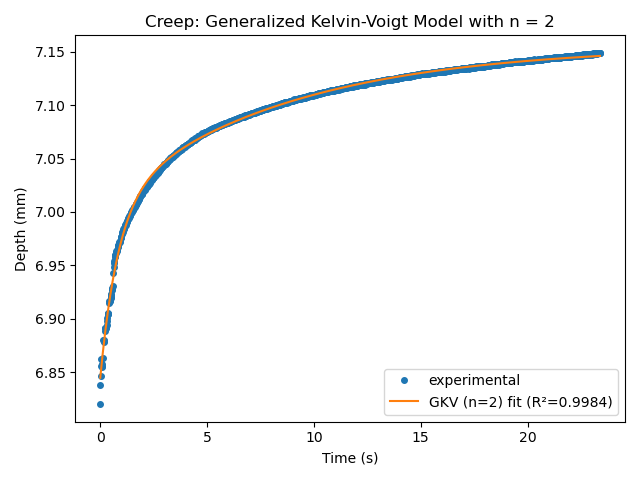

In [10]:
# Plot
tt = np.linspace(float(t.min()), float(t.max()), 400)
plt.figure()
plt.plot(t, h_mm, "o", ms=4, label="experimental")
plt.plot(tt, predict(tt), "-", label=f"GKV (n=2) fit (R²={R2:.4f})")
plt.xlabel("Time (s)"); plt.ylabel("Depth (mm)")
plt.title("Creep: Generalized Kelvin-Voigt Model with n = 2")
plt.legend(loc="lower right"); 
plt.tight_layout()
#if SAVE_PLOTS:
#    out_svg = os.path.join(SAVE_DIR, "fit_GKV.svg")
#    plt.savefig(out_svg, dpi=600)
#    print(f"Saved plot: {out_svg}")
plt.show()
